Data Science Capstone - Week 2
-
## Linear Regression ##
Keshia-Lee Martin

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Loading Data and Setting the Target
The target is the log10 of the Worldwide Revenue. This is log because revenue is heavily skewed by the blockbusters.

In [11]:
movie_box_office = pd.read_csv("movie_box_office_cv2.csv")

# dropping titles that don't have genre, country, language, votes listed
movie_box_office = movie_box_office[movie_box_office['Vote_Count'].notna()].copy()
print('Rows Remaining:', len(movie_box_office))

# target as the random forest: log10 of the worldwide revenue
movie_box_office['Log_Worldwide'] = np.log10(movie_box_office['$Worldwide'])
movie_box_office['Log_Worldwide'].describe().round(3)

Rows Remaining: 4830


count    4830.000
mean        7.758
std         0.514
min         6.222
25%         7.399
50%         7.695
75%         8.090
max         9.447
Name: Log_Worldwide, dtype: float64

## 2. Build the pre-release features
Pre-release features, excluding Rating and Vote_Count, which is post-release.\
Rank and the domestic and foreign revenue columns, because they are pieces of the target.

In [12]:
# Feature names have no spaces, so interaction names read cleaner for later
movie_box_office = movie_box_office.rename(columns={'Science Fiction': 'Sci_Fi', 'TV Movie': 'TV_Movie'})
genre_cols = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama',
              'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
              'Sci_Fi', 'TV_Movie', 'Thriller', 'War', 'Western']

In [13]:
# take all rows and only the columns whose labels fall in this range for country names
country_cols = list(movie_box_office.loc[:, 'Algeria':'Yugoslavia'].columns)

In [14]:
# Release years and also the pandemic years
movie_box_office['Years_Since_2000'] = movie_box_office['Year'] - 2000
movie_box_office['Pandemic_Release'] = movie_box_office['Year'].isin([2020, 2021]).astype(int)

In [17]:
# The 10 most common countries, plus how many countries are on the film
top_countries = {'United States of America': 'Prod_USA', 'United Kingdom': 'Prod_UK',
                 'France': 'Prod_France', 'Japan': 'Prod_Japan', 'China': 'Prod_China',
                 'Germany': 'Prod_Germany', 'Canada': 'Prod_Canada', 'South Korea': 'Prod_South_Korea',
                 'Hong Kong': 'Prod_Hong_Kong', 'India': 'Prod_India'}

# creating new columns from the top countries
production_cols = []
for country in top_countries:
    col_name = top_countries[country]
    movie_box_office[col_name] = movie_box_office[country]
    production_cols.append(col_name)
movie_box_office['Num_Countries'] = movie_box_office[country_cols].sum(axis=1)

In [19]:
# Original language: English is the baseline, so it gets no column
top_languages = {'Japanese': 'Lang_Japanese', 'Chinese (Mandarin)': 'Lang_Mandarin',
                 'French': 'Lang_French', 'Korean': 'Lang_Korean', 'Hindi': 'Lang_Hindi',
                 'German': 'Lang_German', 'Spanish': 'Lang_Spanish',
                 'Chinese (Cantonese)': 'Lang_Cantonese', 'Italian': 'Lang_Italian'}

language_cols = []
for language in top_languages:
    col_name = top_languages[language]
    movie_box_office[col_name] = (movie_box_office['Original_Language'] == language).astype(int)
    language_cols.append(col_name)
named_languages = ['English'] + list(top_languages.keys())
movie_box_office['Lang_Other'] = (~movie_box_office['Original_Language'].isin(named_languages)).astype(int)
language_cols.append('Lang_Other')

In [21]:
feature_cols = ['Years_Since_2000', 'Pandemic_Release', 'Num_Countries'] + genre_cols + language_cols + production_cols
X = movie_box_office[feature_cols]
y = movie_box_office['Log_Worldwide']
print('Number of pre-release features:', len(feature_cols))

Number of pre-release features: 42


## Train/Test

For the train/test split, we are going to do 70/30 and a 5-fold cross validation. This is the same as the random forest workflow. Every model will be scored the same way.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
print('Train rows:', len(X_train), '| Test rows:', len(X_test))

results = {}


def score_model(name, model, X_tr, X_te, cv_rmse):
    train_rmse = mean_squared_error(y_train, model.predict(X_tr)) ** 0.5
    test_pred = model.predict(X_te)
    test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
    test_r2 = r2_score(y_test, test_pred)
    results[name] = {'Train RMSE': round(train_rmse, 3),
                     'CV RMSE': round(cv_rmse, 3),
                     'Test RMSE': round(test_rmse, 3),
                     'Test R2': round(test_r2, 3),
                     'Typical miss (x)': round(10 ** test_rmse, 2)}
    print(name, '| train RMSE', round(train_rmse, 3), '| test RMSE', round(test_rmse, 3),
          '| test R2', round(test_r2, 3))
    return test_pred

Train rows: 3381 | Test rows: 1449


## Baseline ##
Here we are predicting the average for each film

In [24]:
baseline = DummyRegressor(strategy='mean')
cv = -cross_val_score(baseline, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error').mean()
baseline.fit(X_train, y_train)
baseline_pred = score_model('Mean baseline', baseline, X_train, X_test, cv)

Mean baseline | train RMSE 0.511 | test RMSE 0.519 | test R2 -0.0


## Linear Regression ##

Each of the coefficients is in log10. This turns it into a revenue multiplier.

In [26]:
model = LinearRegression()
cv = -cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error').mean()
model.fit(X_train, y_train)
model_pred = score_model('Linear Regression', model, X_train, X_test, cv)

coef_table = pd.DataFrame({'Feature': feature_cols, 'Coef (log10)': model.coef_})
coef_table['Revenue multiplier'] = 10 ** coef_table['Coef (log10)']
coef_table = coef_table.sort_values('Coef (log10)', ascending=False).round(3)
coef_table

Linear Regression | train RMSE 0.417 | test RMSE 0.415 | test R2 0.359


,Feature,Coef (log10),Revenue multiplier
32,Prod_USA,0.308,2.032
4,Adventure,0.157,1.434
17,Sci_Fi,0.154,1.427
36,Prod_China,0.149,1.408
3,Action,0.127,1.339
20,War,0.114,1.301
11,Fantasy,0.098,1.252
5,Animation,0.081,1.206
23,Lang_Mandarin,0.073,1.182
33,Prod_UK,0.068,1.168


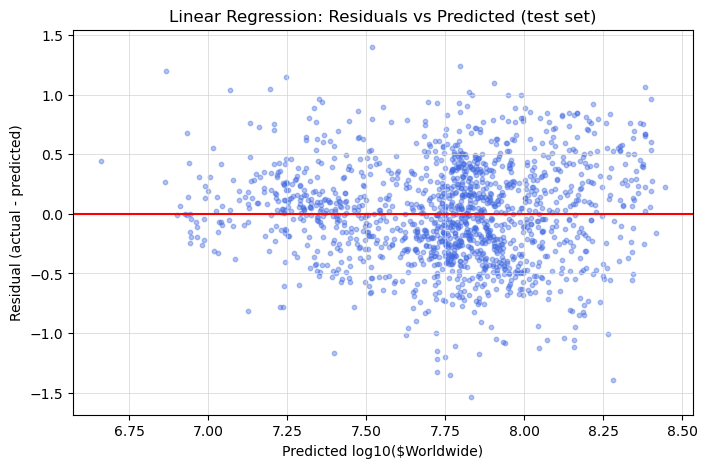

In [33]:
residuals = y_test - model_pred

plt.figure(figsize=(8, 5))
plt.scatter(model_pred, residuals, s=10, alpha=0.4, color='royalblue')
plt.axhline(0, color='red', linewidth=1.5)
plt.xlabel('Predicted log10($Worldwide)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Linear Regression: Residuals vs Predicted (test set)')
plt.grid(color='lightgray', linewidth=0.5)
plt.show()

Linear regression lowered the test RMSE to 0.415 with an R² of 0.36. The pre-release features explain about a third of the variation in revenue. 

A US production had the largest effect, at about 2 times the revenue. Adventure, Sci-Fi, and Action added between 34 and 43 percent. Most non-English films earned about half to two-thirds as much, but Mandarin and Korean films did not. Films released in 2020 and 2021 earned less than half as much.

The residuals are spread evenly around zero with no clear pattern, so a linear model is a reasonable fit.

6. Polynomial and Interaction Terms

A 0/1 flag squared is the same flag, so only the numeric columns keep a squared term.
A pair that shows up in fewer than 10 training films is dropped, because there is too little data to estimate it.

In [34]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_array = poly.fit_transform(X)

new_names = []
for name in poly.get_feature_names_out(X.columns):
    new_names.append(name.replace(' ', ' x '))
X_poly = pd.DataFrame(poly_array, columns=new_names, index=X.index)

numeric_cols = ['Years_Since_2000', 'Num_Countries']
drop_cols = []
for col in X_poly.columns:
    if col.endswith('^2') and col[:-2] not in numeric_cols:
        drop_cols.append(col)
    elif (X_poly.loc[X_train.index, col] != 0).sum() < 10:
        drop_cols.append(col)
X_poly = X_poly.drop(columns=drop_cols)

Xp_train = X_poly.loc[X_train.index]
Xp_test = X_poly.loc[X_test.index]
print('Features before:', len(feature_cols), '| after polynomial + interactions:', X_poly.shape[1])

Features before: 42 | after polynomial + interactions: 489


In [36]:
model_poly = LinearRegression()
cv = -cross_val_score(model_poly, Xp_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error').mean()
model_poly.fit(Xp_train, y_train)
model_poly_pred = score_model('Linear Regression + poly/interactions', model_poly, Xp_train, Xp_test, cv)

Linear Regression + poly/interactions | train RMSE 0.353 | test RMSE 0.42 | test R2 0.345


Adding squared terms and pairs of features raised the number of features from 42 to 489. Plain linear regression overfit. The training error dropped to 0.353, but the cross-validation error rose to 0.444. The test RMSE was 0.420, which is worse than the simple model.

## Ridge Regression
The features are standardized first. alpha is the penalty strength, chosen by 5-fold cross-validation

In [38]:
ridge_pipe = Pipeline([('scale', StandardScaler()), ('model', Ridge())])
ridge_grid = {'model__alpha': [1, 10, 30, 100, 300, 1000, 3000, 10000]}
ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=kfold, scoring='neg_root_mean_squared_error')
ridge_search.fit(Xp_train, y_train)
print('Best alpha:', ridge_search.best_params_['model__alpha'])
ridge_pred = score_model('Ridge (poly)', ridge_search.best_estimator_, Xp_train, Xp_test, -ridge_search.best_score_)

Best alpha: 1000
Ridge (poly) | train RMSE 0.382 | test RMSE 0.403 | test R2 0.397


Ridge shrinks all the coefficients toward zero. With an alpha of 1000, the test RMSE dropped to 0.403 and the R² rose to 0.40. The penalty fixed most of the overfitting.